In [1]:
from shapely.geometry import Polygon
from shapely import polygons as shapely_polygons, unary_union

import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle

In [2]:
LAT        = 52.13896498167249
_lat_rad   = np.radians(LAT)
_M_PER_DEG_LON = 111320 * np.cos(_lat_rad)
_M_PER_DEG_LAT = 110540

In [3]:
def _project_shadow_vectorized(coords, height, ox, oy):
    """
    Build shadow polygon for one building using fully vectorized numpy ops.
    coords : (n, 2) array of exterior ring vertices (closing vertex dropped)
    ox, oy : offset per metre of height, already in degrees
    Returns a Shapely Polygon.
    """
    offset = np.array([ox * height, oy * height])
    shifted = coords + offset

    n = len(coords)
    i = np.arange(n)
    j = (i + 1) % n

    # Each quad: 4 corners × n quads × 2 coords → shape (n, 4, 2)
    quads_coords = np.stack([
        coords[i],    # v_i
        coords[j],    # v_i+1
        shifted[j],   # shifted v_i+1
        shifted[i],   # shifted v_i
    ], axis=1)        # (n, 4, 2)

    # Build all n quads in one call - no Python loop
    quads = shapely_polygons(quads_coords)

    shadow = unary_union([Polygon(coords), Polygon(shifted), *quads])
    return shadow

In [4]:
def calculate_shadow(buildings: gpd.GeoDataFrame, sun_pos: tuple) -> gpd.GeoDataFrame:
    az_deg, alt_deg = sun_pos

    if alt_deg < 2.0:
        return gpd.GeoDataFrame(geometry=[], crs=buildings.crs)

    scale = 1.0 / np.tan(np.radians(alt_deg))
    dx_per_m = -np.sin(np.radians(az_deg)) * scale / _M_PER_DEG_LON
    dy_per_m = -np.cos(np.radians(az_deg)) * scale / _M_PER_DEG_LAT

    shadows = []
    for row in buildings.itertuples():
        shadow = _project_shadow_vectorized(
            np.array(row.geometry.exterior.coords[:-1]),
            row.height,
            dx_per_m,
            dy_per_m,
        )
        shadows.append({
            "original_building_id": row.original_building_id,
            "height": row.height,
            "geometry": shadow,
        })

    return gpd.GeoDataFrame(shadows, crs=buildings.crs)

In [5]:
def plot_shadows_and_buildings(buildings, shadows, sun_pos, whole_day=False):
    az, alt = sun_pos
    fig, ax = plt.subplots(figsize=(12, 12))

    # --- Plot shadows ---
    if len(shadows) > 0:
        shadows.plot(ax=ax, color="#555555", alpha=0.4)

    # --- Plot buildings ---
    buildings.plot(
        ax=ax,
        color="#3a86ff",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color="#3a86ff", alpha=0.8, label="Buildings"),
        mpatches.Patch(color="#555555", alpha=0.4, label="Ground Shadow"),
    ]

    ax.legend(handles=legend_handles, loc="upper right")

    ax.set_title(f"Building Shadow - Azimuth: {az}° | Altitude: {alt}°", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()

    plt.show()

In [6]:
with open("./data/grid_sun_pos.pkl", "rb") as f:
    list_grid = pickle.load(f)

In [23]:
position = list_grid[1760]

In [24]:
buildings_path = "./data/buildings_campus_sp_simplified.fgb"
buildings = gpd.read_file(buildings_path)
shadows = calculate_shadow(buildings, position)

In [25]:
gdf = shadows.dissolve(by="original_building_id", aggfunc={"height": "first"})
gdf.index.name = "building_id"
gdf = gdf.reset_index()

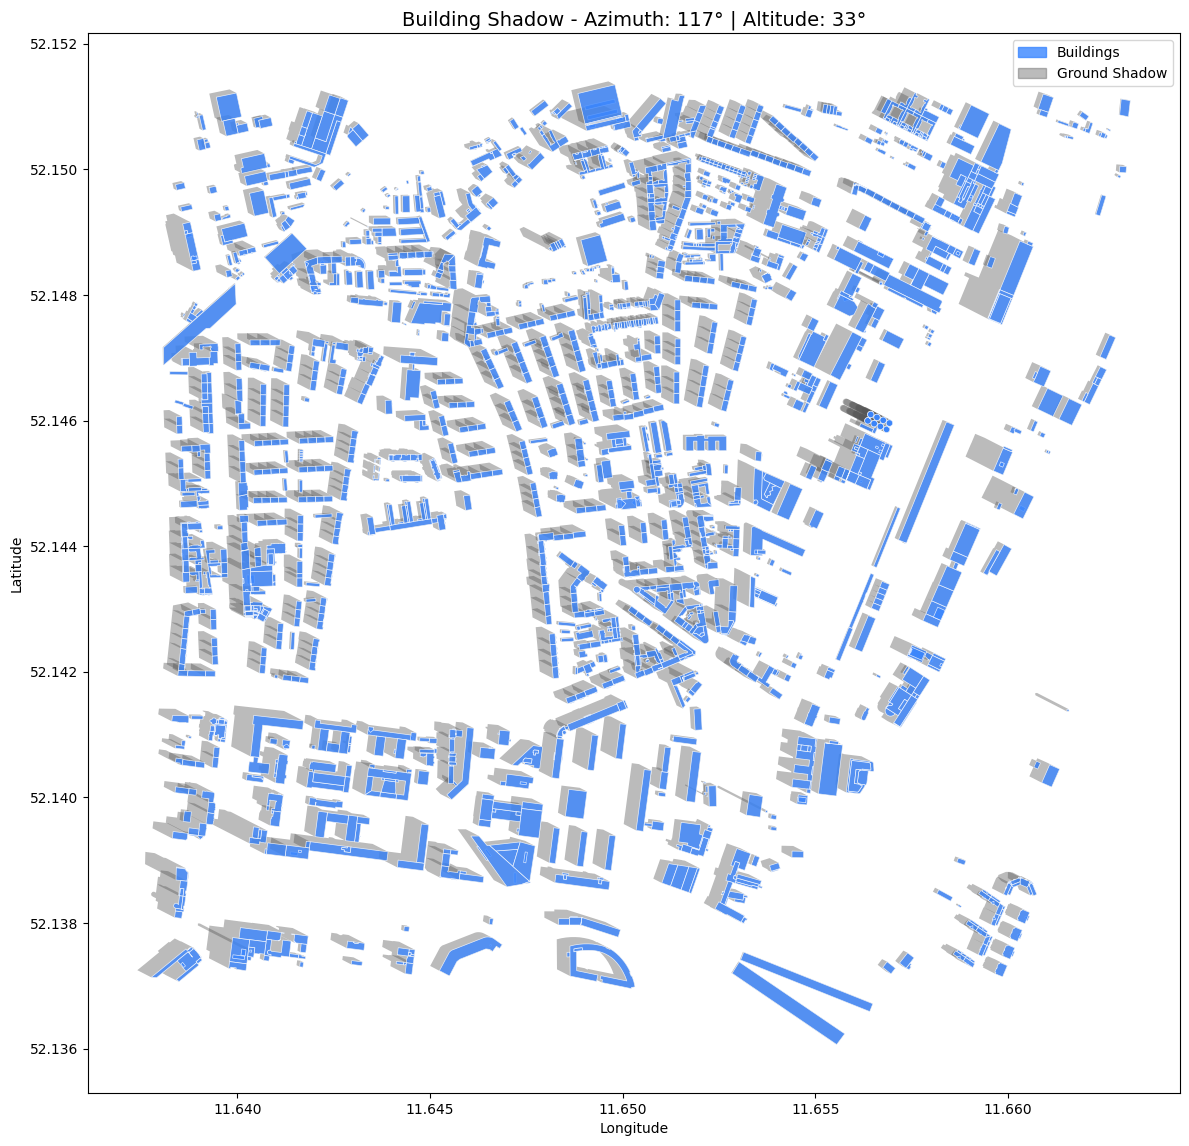

In [26]:
plot_shadows_and_buildings(buildings, gdf, position)

In [22]:
gdf.to_parquet("shadows_test.parquet", compression="snappy")